In [1]:
from tradepy.data.loader import load_future
from tradepy.config.config import load_config, load_symbols, load_feature_config, load_exclude_config
from tradepy.data.cleaner import add_trading_date_by_gap
from tradepy.data.resampler import resample_ohlcv, daily_ohlcv_cummulative
from tradepy.features.generate import generate_features
from tradepy.features.quality_check import data_quality_report
from tradepy.supervised.load import prepare_all
from tradepy.paths import EXCLUDE_CONFIG, SYSTEM_CONFIG
from tradepy.supervised.target import target_triple_barrier_interday
from tradepy.supervised.pretrain import filter_features
from tradepy.supervised.models import GoldLSTM_L1_Move, GoldLSTM_L2_Dir, GoldGRU_L1_Move, GoldGRU_L2_Dir, BasicLSTM_L1_Move, BasicLSTM_L2_Dir, BasicGRU_L1_Move, BasicGRU_L2_Dir
from tradepy.supervised.train import train_walk_forward_2level, grid_search_thresholds
from tradepy.supervised.posttrain import evaluate_model_classification, tune_threshold_wf, save_trading_model_2level
from tradepy.paths import MODELS_DIR

In [2]:
symbols = load_symbols()
cfg = load_config()

In [3]:
symbols

['AD',
 'BP',
 'CL',
 'EC',
 'ES',
 'GC',
 'MFXI',
 'NG',
 'NQ',
 'YM',
 'ZB',
 'ZN',
 'ZS']

In [4]:
ASSET = symbols[5]
MINUTES             = cfg['sampling_minutes']        # 240
RETURN_HORIZON_MIN  = cfg['return_horizon_min']      # 2880

In [5]:
df_final, spec = prepare_all(ASSET, MINUTES, RETURN_HORIZON_MIN, json_config_path="../Data/features_config.json")


In [6]:
spec

{'name': 'Gold',
 'symbol': 'GC',
 'ib_symbol': 'GC',
 'exchange': 'COMEX',
 'currency': 'USD',
 'approx_total_fee_per_side': 2.5,
 'min_slippage_ticks': 1,
 'max_spread_ticks': 4,
 'fallback_margin': 45000,
 'conId': 706903673,
 'multiplier': 100.0,
 'tick_size': 0.1,
 'tick_value': 10.0,
 'trading_hours': '20260425:CLOSED;20260426:1800-20260427:1700;20260427:1800-20260428:1330',
 'liquid_hours': '20260425:CLOSED;20260426:CLOSED;20260427:0930-20260427:1700;20260428:0930-20260428:1330',
 'min_profit_ticks': 2.5,
 'initial_margin': 44136.61,
 'maint_margin': 38379.66,
 'fetched_at': '2026-04-25T14:19:21.740096+00:00'}

In [7]:
exclude = load_exclude_config(MINUTES)

In [8]:
exclude

{'exclude_cols_triple': ['datetime',
  'dtyyyymmdd',
  'trading_date',
  'ticker',
  'per',
  'openint',
  'open',
  'high',
  'low',
  'close',
  'volume',
  'target_bin',
  'target_logret_240',
  'target_ret_240',
  'target_ticks_240'],
 'exclude_more': ['open_day',
  'bb_std',
  'true_range',
  'volume_cum',
  'vpt',
  'obv',
  'ad',
  'hour',
  'minute',
  'dayofweek',
  'day',
  'month',
  'swing_low',
  'swing_low_price',
  'swing_low_strength',
  'swing_high',
  'swing_high_price',
  'swing_high_strength']}

In [9]:
feature_cols_triple = [c for c in df_final.columns if c not in exclude['exclude_cols_triple']]

In [10]:
df_final_triple_real = target_triple_barrier_interday(df_final, spec, return_horizon_days=int(RETURN_HORIZON_MIN/60/24), profit_factor=1.8, tp_atr_mult=1.4, sl_atr_mult=1.2)
df_final_triple_real["target_class"] = df_final_triple_real[f"target_tb_{int(RETURN_HORIZON_MIN/60/24)}d"]

In [11]:
features_finales_test, params = filter_features(df_final_triple_real, feature_cols_triple, 'target_class')

Eliminando 54 features redundantes por correlación
Configuración sugerida:
{'lookback': 30, 'train_size': 6000, 'test_size': 180, 'gap': 12, '_candles_per_day': 6, '_horizon_bars': 12}


KeyError: 'target_regression'

In [12]:
df_final_triple_real

,datetime,open,high,low,close,volume,openint,ticker,per,trading_date,...,swing_extension,bars_between_swing_highs,bars_between_swing_lows,swing_high_velocity,swing_low_velocity,bars_between_swings,swing_cycle_ratio,target_tb_2d,logreturn_tb_2d,target_class
0,2006-12-04 08:00:00,651.2,653.6,651.0,653.4,610,0.0,GC,240min,2006-12-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0
1,2006-12-04 12:00:00,653.4,653.9,651.9,652.3,741,0.0,GC,240min,2006-12-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-0.003686,0.0
2,2006-12-04 16:00:00,652.2,652.8,650.6,651.6,302,0.0,GC,240min,2006-12-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-0.003739,0.0
3,2006-12-04 20:00:00,651.5,652.0,649.5,651.0,1106,0.0,GC,240min,2006-12-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,-0.003860,0.0
4,2006-12-05 00:00:00,651.0,651.6,644.5,650.6,9571,0.0,GC,240min,2006-12-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30564,2026-01-17 08:00:00,4588.8,4602.1,4586.8,4601.1,3939,0.0,GC,240min,2026-01-17,...,-0.274854,6.0,3.0,14.250000,28.5,0.0,1.666667,2.0,0.007183,2.0
30565,2026-01-19 08:00:00,4633.7,4698.0,4622.2,4684.2,39499,0.0,GC,240min,2026-01-19,...,0.697076,6.0,3.0,14.250000,28.5,0.0,1.666667,1.0,NaN,1.0
30566,2026-01-19 12:00:00,4684.3,4685.5,4660.0,4671.2,22930,0.0,GC,240min,2026-01-19,...,0.545029,6.0,3.0,14.250000,28.5,0.0,1.666667,1.0,NaN,1.0
30567,2026-01-19 16:00:00,4670.9,4684.3,4666.4,4668.4,18219,0.0,GC,240min,2026-01-19,...,-0.186281,3.0,3.0,52.966667,28.5,3.0,0.000000,1.0,NaN,1.0


In [ ]:
results, results_by_fold, model_l1, model_l2, sc = train_walk_forward_2level(
    df_final_triple_real,
    features_finales_test,
    'target_class',
    model_class_l1=GoldLSTM_L1_Move,
    model_class_l2=GoldLSTM_L2_Dir,
    train_size=params["train_size"],
    test_size=params["test_size"],
    gap=params["gap"],
    lookback=params["lookback"],
    epochs=15,
    batch_size=256,
    lr=5e-4,
    threshold_move=0.6,
    threshold_dir=0.55
)

WF 2-Level:   0%|          | 0/134 [00:00<?, ?it/s]E:\Futuro\MLAlgoTrading\TradingBots\tradepy\tradepy\supervised\train.py:339: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched_l1.step()
E:\Futuro\MLAlgoTrading\TradingBots\tradepy\tradepy\supervised\train.py:379: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-ra

📊 --- CLASIFICACIÓN POR CLASE ---
              precision    recall  f1-score   support

    SELL (0)       0.21      0.14      0.17      4816
    HOLD (1)       0.62      0.75      0.68     14783
     BUY (2)       0.22      0.14      0.17      4521

    accuracy                           0.51     24120
   macro avg       0.35      0.34      0.34     24120
weighted avg       0.46      0.51      0.48     24120



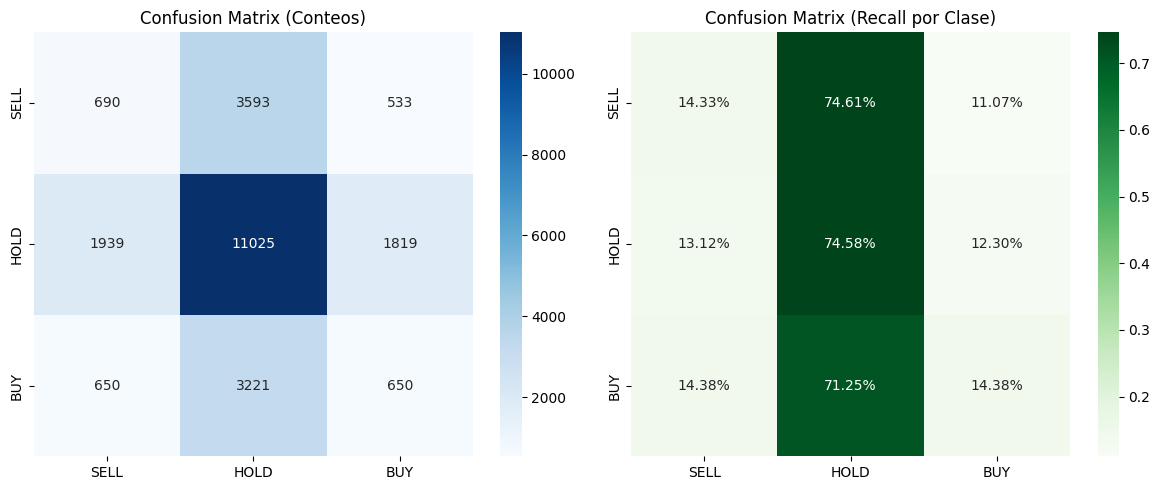


⭐ Métricas Globales:
Accuracy: 0.5126
F1-Score (Macro): 0.3397  <-- Si es < 0.33, el modelo es puro azar


{'accuracy': 0.5126451077943616, 'f1_macro': 0.3397344093461416}

In [14]:
evaluate_model_classification(results)

In [21]:
best_params, df_grid = grid_search_thresholds(results, move_thresholds=[0.40, 0.45, 0.48, 0.50, 0.52], metric='f1_macro')


Métrica: f1_macro
Mejor score: 0.3452 con {'threshold_move': 0.48, 'threshold_dir': 0.55}

Top 10:
 threshold_move  threshold_dir  f1_macro
           0.48           0.55    0.3452
           0.50           0.55    0.3451
           0.52           0.55    0.3448
           0.45           0.55    0.3446
           0.52            NaN    0.3443
           0.52           0.50    0.3443
           0.50            NaN    0.3439
           0.40           0.55    0.3439
           0.50           0.50    0.3439
           0.48            NaN    0.3437


In [13]:
results_v2, results_by_fold_v2, model_l1_v2, model_l2_v2, sc_v2 = train_walk_forward_2level(
    df_final_triple_real,
    features_finales_test,
    'target_class',
    model_class_l1=BasicLSTM_L1_Move,
    model_class_l2=BasicLSTM_L2_Dir,
    train_size=params["train_size"],
    test_size=params["test_size"],
    gap=params["gap"],
    lookback=params["lookback"],
    epochs=15,
    batch_size=256,
    lr=5e-4,
    threshold_move=0.6,
    threshold_dir=0.55
)

WF 2-Level:   0%|          | 0/134 [00:00<?, ?it/s]E:\Futuro\MLAlgoTrading\TradingBots\tradepy\tradepy\supervised\train.py:339: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched_l1.step()
E:\Futuro\MLAlgoTrading\TradingBots\tradepy\tradepy\supervised\train.py:379: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-ra

📊 --- CLASIFICACIÓN POR CLASE ---
              precision    recall  f1-score   support

    SELL (0)       0.36      0.18      0.24      4816
    HOLD (1)       0.64      0.82      0.72     14783
     BUY (2)       0.35      0.21      0.26      4521

    accuracy                           0.58     24120
   macro avg       0.45      0.40      0.41     24120
weighted avg       0.53      0.58      0.54     24120



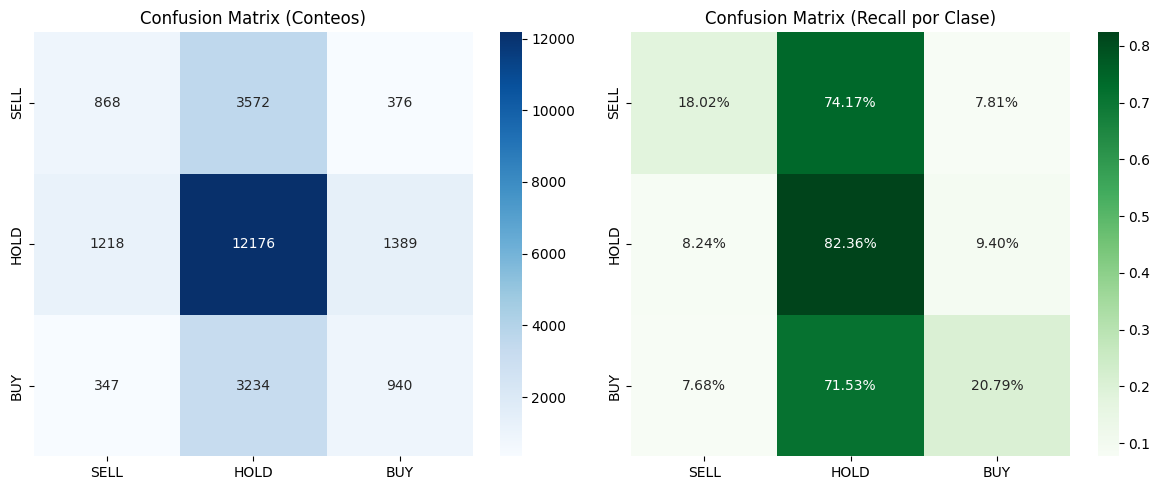


⭐ Métricas Globales:
Accuracy: 0.5798
F1-Score (Macro): 0.4070  <-- Si es < 0.33, el modelo es puro azar


{'accuracy': 0.5797678275290216, 'f1_macro': 0.40695770291442535}

In [ ]:
evaluate_model_classification(results_v2)

In [15]:
best_params_v2, df_grid_v2 = grid_search_thresholds(results_v2, move_thresholds=[0.40, 0.45, 0.48, 0.50, 0.52], metric='f1_macro')


Métrica: f1_macro
Mejor score: 0.4167 con {'threshold_move': 0.52, 'threshold_dir': 0.5}

Top 10:
 threshold_move  threshold_dir  f1_macro
           0.52           0.50    0.4167
           0.52            NaN    0.4166
           0.50            NaN    0.4155
           0.40           0.55    0.4152
           0.52           0.55    0.4150
           0.50           0.50    0.4149
           0.48           0.55    0.4148
           0.50           0.55    0.4146
           0.45           0.55    0.4146
           0.48            NaN    0.4140


In [16]:
results_gru, results_gru_by_fold, model_l1_gru, model_l2_gru, sc_gru = train_walk_forward_2level(
    df_final_triple_real,
    features_finales_test,
    'target_class',
    model_class_l1=GoldGRU_L1_Move,   # ← GRU
    model_class_l2=GoldGRU_L2_Dir,    # ← GRU
    train_size=params["train_size"],
    test_size=params["test_size"],
    gap=params["gap"],
    lookback=24,
    epochs=15,
    batch_size=256,
    lr=5e-4,
    threshold_move=0.6,
    threshold_dir=0.55
)

WF 2-Level:   0%|          | 0/134 [00:00<?, ?it/s]E:\Futuro\MLAlgoTrading\TradingBots\tradepy\tradepy\supervised\train.py:339: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched_l1.step()
E:\Futuro\MLAlgoTrading\TradingBots\tradepy\tradepy\supervised\train.py:379: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-ra

📊 --- CLASIFICACIÓN POR CLASE ---
              precision    recall  f1-score   support

    SELL (0)       0.23      0.15      0.19      4816
    HOLD (1)       0.62      0.76      0.68     14783
     BUY (2)       0.24      0.15      0.18      4521

    accuracy                           0.52     24120
   macro avg       0.36      0.35      0.35     24120
weighted avg       0.47      0.52      0.49     24120



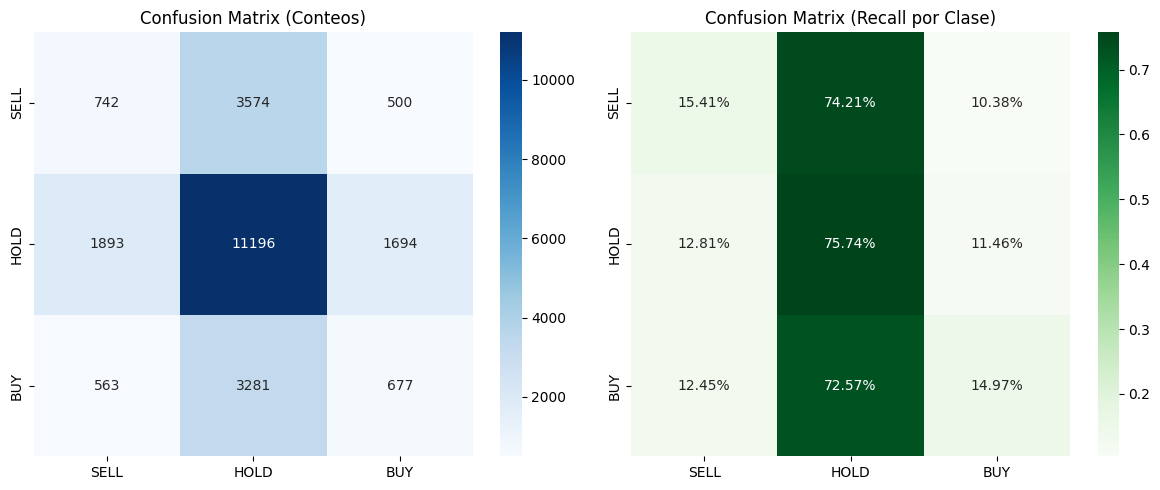


⭐ Métricas Globales:
Accuracy: 0.5230
F1-Score (Macro): 0.3501  <-- Si es < 0.33, el modelo es puro azar


{'accuracy': 0.5230099502487562, 'f1_macro': 0.3501076460865394}

In [17]:
evaluate_model_classification(results_gru)

In [18]:
best_params_gru, df_grid_gru = grid_search_thresholds(results_gru, metric='f1_macro')


Métrica: f1_macro
Mejor score: 0.3584 con {'threshold_move': 0.6, 'threshold_dir': 0.5}

Top 10:
 threshold_move  threshold_dir  f1_macro
           0.60           0.50    0.3584
           0.60            NaN    0.3584
           0.55            NaN    0.3555
           0.55           0.50    0.3555
           0.50            NaN    0.3540
           0.50           0.50    0.3540
           0.50           0.55    0.3532
           0.55           0.55    0.3513
           0.60           0.55    0.3501
           0.50           0.60    0.3489


In [26]:
results_gru_v2, results_gru_by_fold_v2, model_l1_gru_v2, model_l2_gru_v2, sc_gru_v2 = train_walk_forward_2level(
    df_final_triple_real,
    features_finales_test,
    'target_class',
    model_class_l1=BasicGRU_L1_Move,
    model_class_l2=BasicGRU_L2_Dir,
    train_size=params["train_size"],
    test_size=params["test_size"],
    gap=params["gap"],
    lookback=24,
    epochs=15,
    batch_size=256,
    lr=5e-4,
    threshold_move=0.6,
    threshold_dir=0.55
)

WF 2-Level:   0%|          | 0/134 [00:00<?, ?it/s]E:\Futuro\MLAlgoTrading\TradingBots\tradepy\tradepy\supervised\train.py:339: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched_l1.step()
E:\Futuro\MLAlgoTrading\TradingBots\tradepy\tradepy\supervised\train.py:379: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-ra

📊 --- CLASIFICACIÓN POR CLASE ---
              precision    recall  f1-score   support

    SELL (0)       0.36      0.19      0.25      4816
    HOLD (1)       0.64      0.82      0.72     14783
     BUY (2)       0.36      0.23      0.28      4521

    accuracy                           0.58     24120
   macro avg       0.45      0.41      0.42     24120
weighted avg       0.53      0.58      0.54     24120



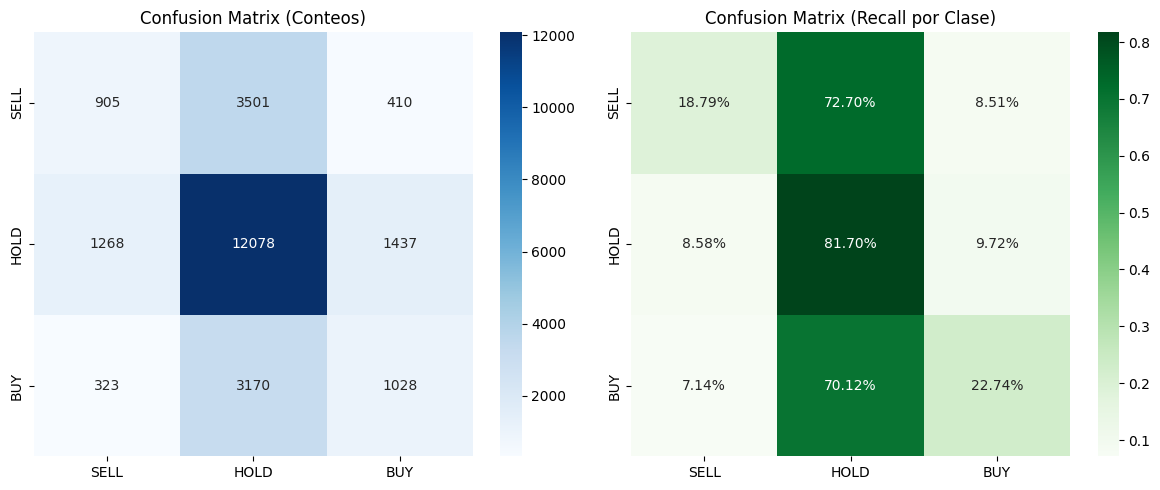


⭐ Métricas Globales:
Accuracy: 0.5809
F1-Score (Macro): 0.4153  <-- Si es < 0.33, el modelo es puro azar


{'accuracy': 0.5808872305140962, 'f1_macro': 0.41530429712472855}

In [27]:
evaluate_model_classification(results_gru_v2)

In [28]:
best_params_gru_v2, df_grid_gru_v2 = grid_search_thresholds(results_gru_v2, metric='f1_macro')


Métrica: f1_macro
Mejor score: 0.4254 con {'threshold_move': 0.5, 'threshold_dir': 0.5}

Top 10:
 threshold_move  threshold_dir  f1_macro
           0.50           0.50    0.4254
           0.50            NaN    0.4254
           0.55            NaN    0.4240
           0.55           0.50    0.4240
           0.60            NaN    0.4219
           0.60           0.50    0.4219
           0.55           0.55    0.4184
           0.50           0.55    0.4181
           0.65            NaN    0.4159
           0.65           0.50    0.4159


In [19]:
# model_params = {"input_dim": len(features_finales_test), "output_dim": 2}

# save_trading_model_2level(
#     model_l1, model_l2, sc,
#     features_finales_test,
#     model_params,
#     best_thresholds=best_params,
#     path=f"{MODELS_DIR}/{ASSET.lower()}/trading_model_lstm_2level"
# )

# # Para el GRU cuando lo tengas:
# save_trading_model_2level(
#     model_l1_gru, model_l2_gru, sc_gru,
#     features_finales_test,
#     model_params,
#     best_thresholds=best_params_gru,
#     path=f"{MODELS_DIR}/{ASSET.lower()}/trading_model_gru_2level"
# )